In [1]:
import sys
import os
import time
import math
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support
from torchsummary import summary

sys.path.append('..')

# Project modules
from src.utility.config import BASELINE_MODEL_PATH, QUANTIZED_MODELS
from src.utility.utils import get_data_loaders
from src.model import CNN

# Configuration
# Force CPU for fair latency comparison (Float32 CPU vs INT8 CPU)
EVAL_DEVICE = torch.device('cpu') 
BATCH_SIZE = 32
MODELS_TO_EVALUATE = ["Baseline", "Affine", "Symmetric", "PoT"]

sns.set_theme(style="whitegrid")
print(f"Evaluation Configured on Device: {EVAL_DEVICE}")

Evaluation Configured on Device: cpu


In [2]:
def load_model(model_name, num_classes):
    """
    Unified loader for Baseline (StateDict) and Quantized (TorchScript).
    """
    if model_name == "Baseline":
        if not os.path.exists(BASELINE_MODEL_PATH):
            print(f"Baseline not found at {BASELINE_MODEL_PATH}")
            return None
        model = CNN(num_classes=num_classes)
        model.load_state_dict(torch.load(BASELINE_MODEL_PATH, map_location=EVAL_DEVICE))
        model.eval()
        return model.to(EVAL_DEVICE)
    else:
        path = os.path.join(QUANTIZED_MODELS, f"model_{model_name}_PTQ.pt")
        if not os.path.exists(path):
            print(f"Quantized model not found: {path}")
            return None
        # Load TorchScript model
        model = torch.jit.load(path, map_location=EVAL_DEVICE)
        model.eval()
        return model

def verify_quantization(model, model_name):
    """
    Scientifically verifies quantization by inspecting the full graph recursively.
    """
    # 1. Check Baseline
    if model_name == "Baseline":
        try:
            first_param = next(model.parameters())
            print("   Type: Standard nn.Module")
            print(f"   Weight Dtype: {first_param.dtype}")
        except:
             print("   Type: Standard nn.Module (Empty or Scripted)")
        return

    # 2. Check Quantized (TorchScript)
    if isinstance(model, torch.jit.ScriptModule):
        model_str = str(model)
        graph_str = str(model.graph)
        
        # A) Check for Class/Layer Names in the structure
        quant_keywords = ["Quantized", "quantized", "QFunctional", "Quantize", "DeQuantize"]
        found_keywords = [k for k in quant_keywords if k in model_str]
        
        # B) Check for Low-Level Ops in the Computation Graph
        quant_ops_to_check = [
            "quantized::conv2d", 
            "quantized::linear", 
            "quantized::add", 
            "quantized::mul", 
            "quantized::cat"
        ]
        found_ops = [op for op in quant_ops_to_check if op in graph_str]
        
        if found_keywords or found_ops:
            print("   Status: Verified Quantized Structure")

In [3]:
def evaluate_model_comprehensive(model, loader, device):
    """
    Runs inference and calculates:
    - Accuracy, Precision, Recall, F1 (Weighted)
    - Latency (ms/img), Throughput (img/sec)
    """
    model.eval()
    model.to(device)
    
    all_preds = []
    all_targets = []
    total_samples = 0
    
    # 1. Warm-up 
    warmup_batches = 5
    with torch.no_grad():
        for i, (data, _) in enumerate(loader):
            if i >= warmup_batches: break
            data = data.to(device)
            _ = model(data)          

    # 2. Inference Loop & Timing
    start_time = time.time()
    
    with torch.no_grad():
        for data, target in loader:
            data = data.to(device)
            # Targets stay on CPU to save transfer time
            
            output = model(data)
            preds = output.argmax(dim=1).cpu().numpy()
            
            all_preds.extend(preds)
            all_targets.extend(target.numpy())
            total_samples += len(data)
            
    end_time = time.time()
    
    # 3. Calculate Metrics
    duration_sec = end_time - start_time
    latency_ms = (duration_sec / total_samples) * 1000
    throughput = total_samples / duration_sec
    
    # Sklearn metrics (Weighted average handles class imbalance)
    accuracy = accuracy_score(all_targets, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_targets, all_preds, average='weighted', zero_division=0
    )
    
    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Latency (ms)": latency_ms,
        "Throughput (img/s)": throughput,
        "Total Time (s)": duration_sec,
        "Predictions": all_preds,
        "Targets": all_targets
    }

In [4]:
def _check_power_of_two(scales):
    """
    Scientific check: Returns True if ALL scales are perfect powers of two (2^k).
    Formula: If log2(scale) is an integer, then scale is a power of two.
    """
    # Guard against zero scales to prevent -inf
    scales = torch.max(scales, torch.tensor(1e-10))
    
    # Calculate log2 of scales
    log_scales = torch.log2(scales)
    
    # Check deviation from nearest integer
    # Using 1e-4 tolerance to be robust against float precision noise
    is_pot = torch.all(torch.abs(log_scales - torch.round(log_scales)) < 1e-4)
    return is_pot.item()

def _print_stats(tensor: torch.Tensor, is_quantized: bool):
    """
    Prints shape, dtype, and intelligently detects the quantization method 
    based on Scheme (Granularity) and Zero Points.
    """
    print(f"Shape: {tensor.shape}")
    print(f"Dtype: {tensor.dtype}")

    if not is_quantized:
        # Standard Float32
        print(f"Values: {tensor.detach().flatten()[:5].tolist()}")
        return

    # Quantized Specifics
    print(f"Scheme: {tensor.qscheme()}")
    print(f"Raw Int8: {tensor.int_repr().flatten()[:5].tolist()}")

    # 1. Per-Channel Detection (Weights)
    if tensor.qscheme() in (torch.per_channel_affine, torch.per_channel_symmetric):
        zps = tensor.q_per_channel_zero_points()
        scales = tensor.q_per_channel_scales()
        
        print(f"Zero Points (First 5): {zps[:5].tolist()}")
        print(f"Scales (First 5): {scales[:5].tolist()}")
        
        # Check properties
        is_zp_zero = torch.all(zps == 0)
        is_pot = _check_power_of_two(scales)
        
        # LOGIC TREE
        if is_zp_zero:
            # Both Symmetric and PoT have ZP=0.
            if is_pot:
                print("Method Detected: Power-of-Two (PoT)")
                print("Fingerprint: Per-Channel, ZP=0, Scales=2^k")
            else:
                print("Method Detected: Symmetric (Standard)")
                print("Fingerprint: Per-Channel, ZP=0, Linear Scales")
        else:
            # If ZP is NOT zero, it is mathematically Affine (Asymmetric).
            print("Method Detected: Affine (Asymmetric Weights)")
            print("Fingerprint: Per-Channel, Non-Zero ZP")

    # 2. Per-Tensor Detection (Activations or Scalar Weights)
    elif tensor.qscheme() in (torch.per_tensor_affine, torch.per_tensor_symmetric):
        zp = tensor.q_zero_point()
        scale = tensor.q_scale()
        print(f"   Zero Point: {zp}")
        print(f"   Scale: {scale}")
        
        if zp == 0:
             print("Method Detected: Symmetric (Per-Tensor)")
        else:
             print("Method Detected: Affine (Per-Tensor)")
             print("Fingerprint: Global Scale, Non-Zero ZP")

def inspect_first_layer_weights(model, model_name: str):
    """
    Inspects 'conv1' weights for both Float32 and Quantized models.
    """
    print(f"\nInspecting: {model_name}")

    # 1. Guard Clause: Check if layer exists
    if not hasattr(model, 'conv1'):
        print("Error: 'conv1' layer not found.")
        return

    layer = model.conv1

    try:
        # 2. Check for Quantized Packed Parameters (TorchScript/FBGEMM)
        if hasattr(layer, '_packed_params'):
            weight, _ = layer._packed_params.unpack()
            _print_stats(weight, is_quantized=True)
            
        # 3. Check for Standard Weight (Float32)
        elif hasattr(layer, 'weight'):
            if layer.weight.dtype in (torch.qint8, torch.quint8):
                 # Handle eager mode quantized weights that aren't packed yet
                 _print_stats(layer.weight, is_quantized=True)
            else:
                 _print_stats(layer.weight, is_quantized=False)
            
        else:
            print("Warning: Unknown layer structure.")

    except Exception as e:
        print(f"Error: {e}")

In [5]:
def plot_confusion_matrix(targets, preds, class_names, title="Confusion Matrix"):
    from sklearn.metrics import confusion_matrix
    # Plot only Top-15 classes to keep it readable
    from collections import Counter
    
    counts = Counter(targets)
    top_classes = [c for c, _ in counts.most_common(15)]
    
    # Filter data
    mask = np.isin(targets, top_classes) & np.isin(preds, top_classes)
    filt_t = np.array(targets)[mask]
    filt_p = np.array(preds)[mask]
    
    cm = confusion_matrix(filt_t, filt_p, labels=top_classes)
    labels = [class_names[i] for i in top_classes] if class_names else top_classes
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

def get_sample_images(loader, num=32):
    """Helper to extract raw images for visualization"""
    data, targets = next(iter(loader))
    return data[:num], targets[:num]

def plot_visual_comparison(images, preds_base, preds_quant, targets, class_names, title="Comparison"):
    """
    Visualizes Baseline vs Quantized Predictions.
    Green = Both Correct | Orange = Disagreement | Red = Both Wrong
    """
    n = len(images)
    rows = math.ceil(n / 8)
    fig, axes = plt.subplots(rows, 8, figsize=(20, 3 * rows))
    axes = axes.flatten()
    
    for i in range(n):
        ax = axes[i]
        img = images[i].permute(1, 2, 0).numpy()
        img = (img * 0.5) + 0.5 # Unnormalize
        ax.imshow(np.clip(img, 0, 1))
        
        pb, pq, t = preds_base[i], preds_quant[i], targets[i]
        
        if pb == pq == t:
            color = 'green' # Perfect
            txt = "OK"
        elif pb != pq:
            color = 'orange' # Quantization Error
            txt = "DIFF"
        else:
            color = 'red' # Model Error
            txt = "ERR"
            
        lbl = class_names[pq] if class_names else str(pq)
        ax.set_title(f"{lbl}\n[{txt}]", color=color, fontweight='bold', fontsize=9)
        ax.axis('off')
        
    for j in range(n, len(axes)): axes[j].axis('off')
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


Starting Scientific Evaluation of 4 Models

Inspecting: Baseline
Shape: torch.Size([32, 3, 3, 3])
Dtype: torch.float32
Values: [0.13093169033527374, -0.005102028604596853, -0.25144273042678833, 0.2563275992870331, 0.11988546699285507]
Running Inference on 1364 samples...
Result: Acc=91.20% | Latency=5.67 ms

Inspecting: Affine
Shape: torch.Size([32, 3, 3, 3])
Dtype: torch.qint8
Scheme: torch.per_tensor_affine
Raw Int8: [32, 0, -58, 61, 29]
   Zero Point: 1
   Scale: 0.0042410860769450665
Method Detected: Affine (Per-Tensor)
Fingerprint: Global Scale, Non-Zero ZP
Running Inference on 1364 samples...
Result: Acc=90.69% | Latency=2.56 ms

Inspecting: Symmetric
Shape: torch.Size([32, 3, 3, 3])
Dtype: torch.qint8
Scheme: torch.per_channel_affine
Raw Int8: [60, -2, -115, 117, 55]
Zero Points (First 5): [0, 0, 0, 0, 0]
Scales (First 5): [0.0021889442577958107, 0.003546810010448098, 0.002901024417951703, 0.0028751397039741278, 0.0023940824903547764]
Method Detected: Symmetric (Standard)
Finge

,Accuracy,F1-Score,Precision,Recall,Latency (ms),Throughput (img/s),Speedup (x)
Model,,,,,,,
Baseline,0.9120,0.9118,0.9228,0.9120,5.6682,176.4234,1.0000
Affine,0.9069,0.9069,0.9197,0.9069,2.5558,391.2648,2.2178
Symmetric,0.8878,0.8873,0.9056,0.8878,2.4245,412.4553,2.3379
PoT,0.9003,0.9008,0.9142,0.9003,2.4380,410.1644,2.3249


Plotting Confusion Matrix: Baseline...


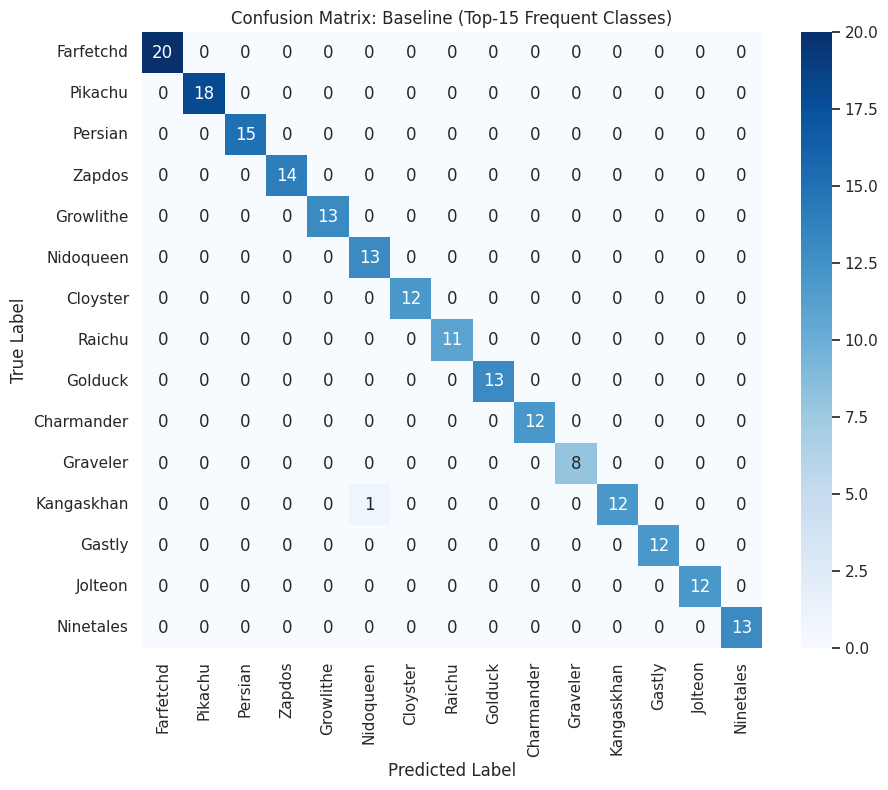

Plotting Confusion Matrix: Affine...


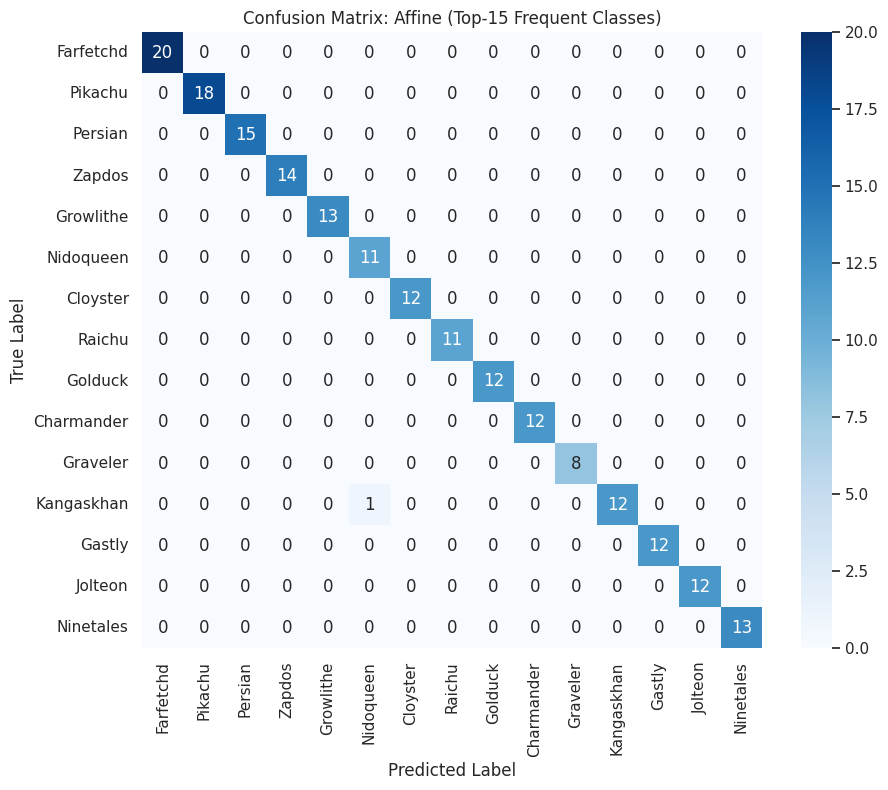

Plotting Confusion Matrix: Symmetric...


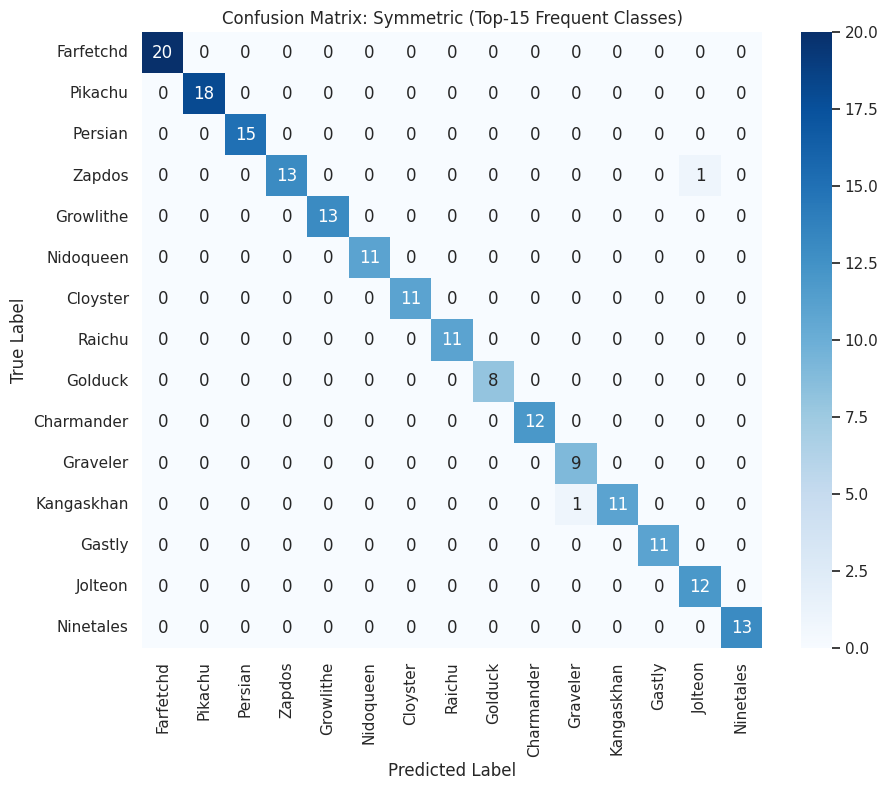

Plotting Confusion Matrix: PoT...


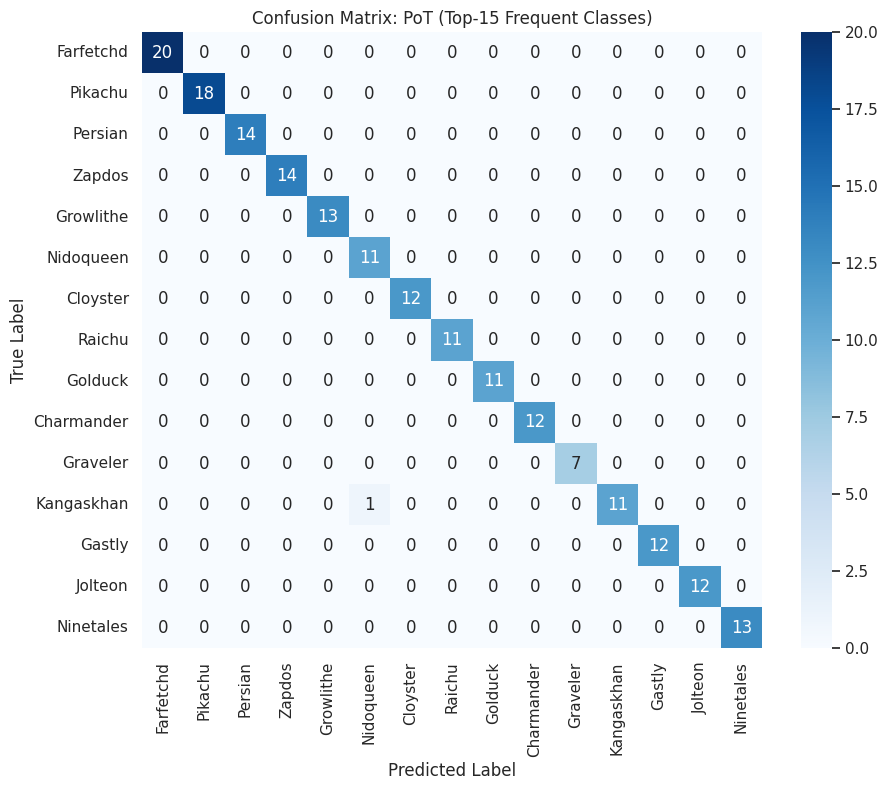

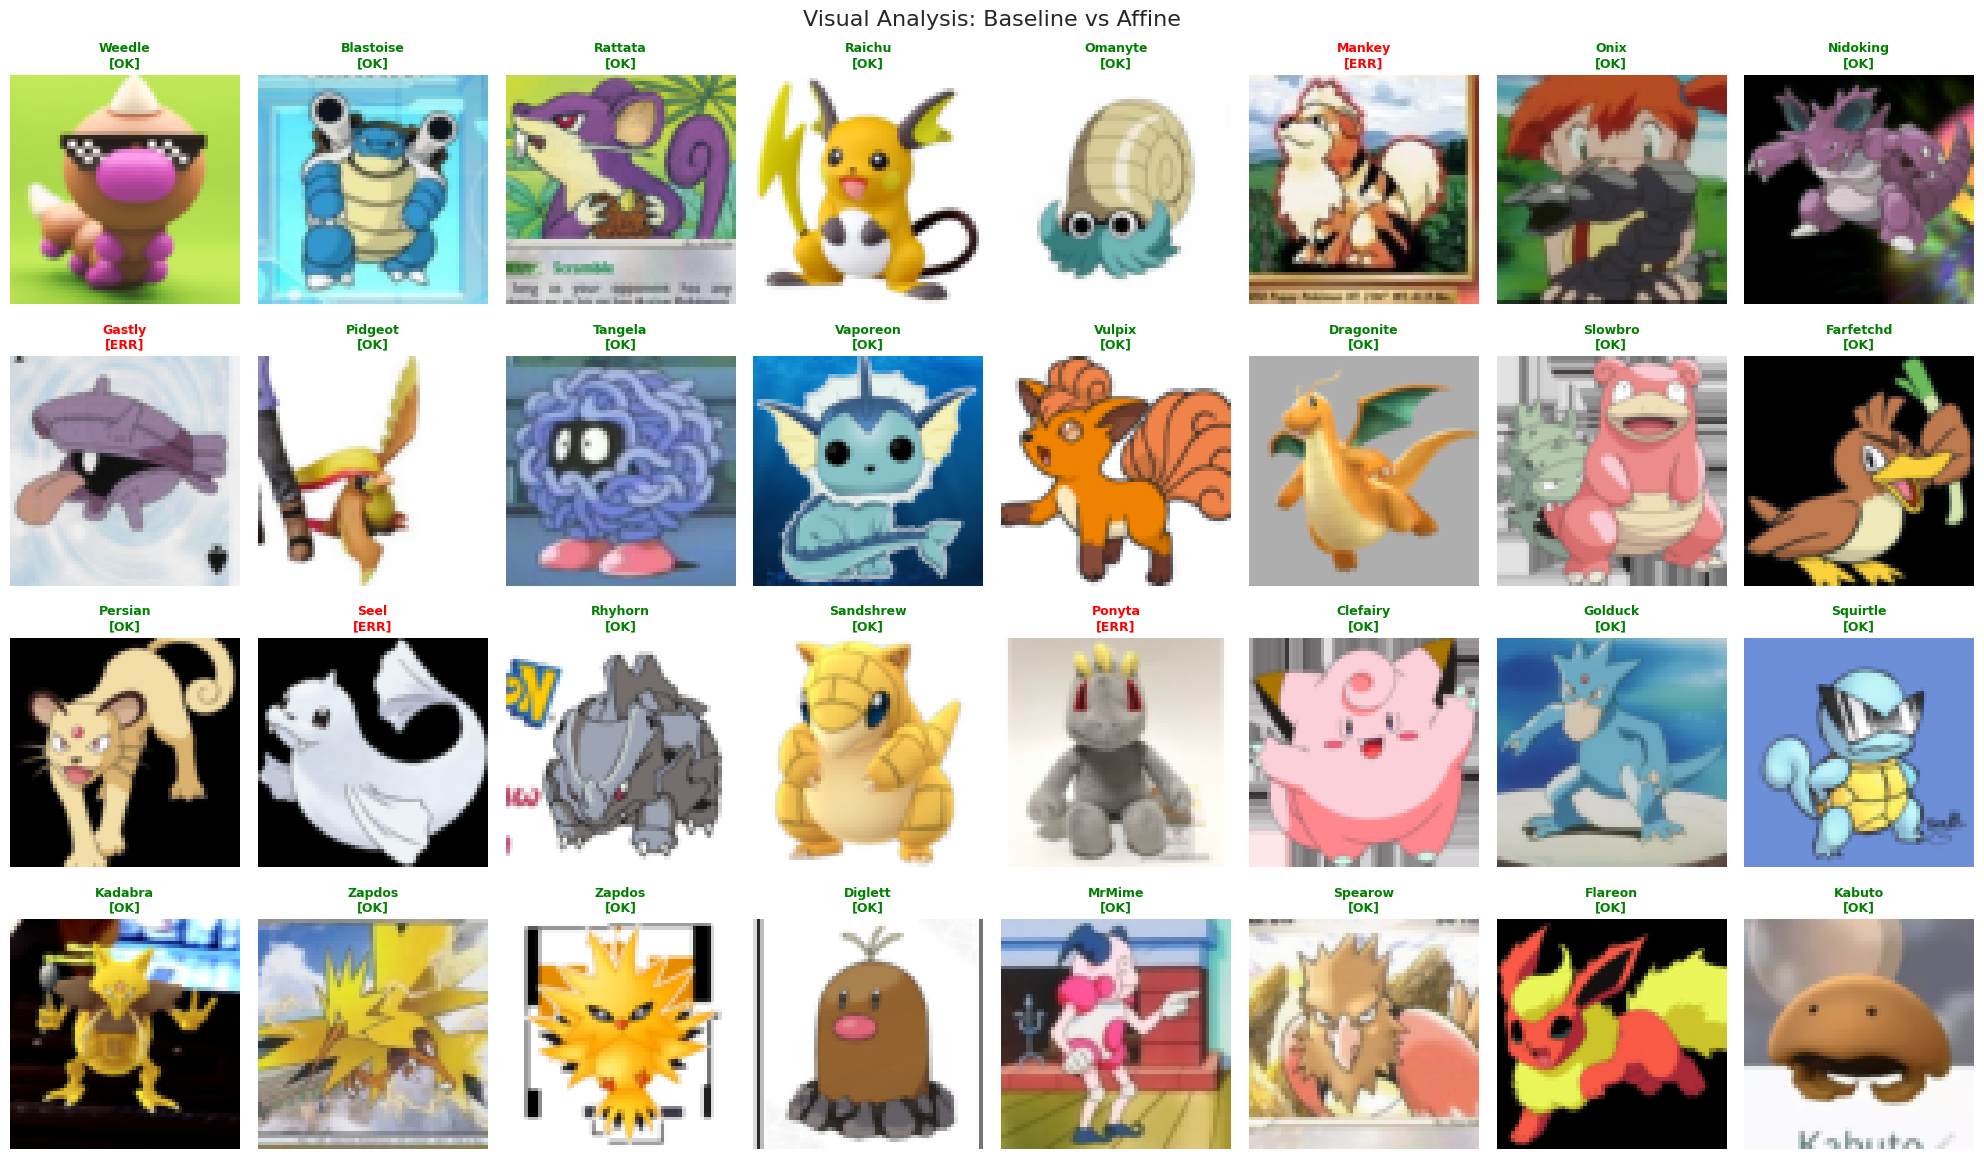

In [6]:
# 1. Load Data
train_loader, test_loader, num_classes = get_data_loaders()

# Get class names
if hasattr(test_loader.dataset, 'classes'):
    class_names = test_loader.dataset.classes
elif hasattr(test_loader.dataset, 'dataset') and hasattr(test_loader.dataset.dataset, 'classes'):
    class_names = test_loader.dataset.dataset.classes
else:
    class_names = [str(i) for i in range(num_classes)]

# 2. Main Evaluation Loop
results_table = []
predictions_store = {}  # Store predictions for visualization
targets_store = {}      # Store targets for confusion matrix

print(f"\nStarting Scientific Evaluation of {len(MODELS_TO_EVALUATE)} Models")

for model_name in MODELS_TO_EVALUATE:
    # A. Load Model
    model = load_model(model_name, num_classes)
    if model is None:
        continue
    
    # B. Scientific Verification (Graph & Weights)
    inspect_first_layer_weights(model, model_name) # Checks weights/scales/PoT status

    # C. Run Comprehensive Evaluation
    print(f"Running Inference on {len(test_loader.dataset)} samples...")

    metrics = evaluate_model_comprehensive(model, test_loader, EVAL_DEVICE)

    # D. Store Results
    res_entry = {
        "Model": model_name,
        "Accuracy": metrics["Accuracy"],
        "F1-Score": metrics["F1-Score"],
        "Precision": metrics["Precision"],
        "Recall": metrics["Recall"],
        "Latency (ms)": metrics["Latency (ms)"],
        "Throughput (img/s)": metrics["Throughput (img/s)"]
    }
    
    # Calculate Speedup vs Baseline (Assumes Baseline is run first)
    if results_table and results_table[0]["Model"] == "Baseline":
        base_lat = results_table[0]["Latency (ms)"]
        res_entry["Speedup (x)"] = base_lat / res_entry["Latency (ms)"]
    else:
        res_entry["Speedup (x)"] = 1.0
        
    results_table.append(res_entry)
    
    # Store raw predictions for plotting later
    predictions_store[model_name] = metrics["Predictions"]
    targets_store[model_name] = metrics["Targets"]
    
    print(f"Result: Acc={metrics['Accuracy']:.2%} | Latency={metrics['Latency (ms)']:.2f} ms")

# 3. Final Scientific Results Table
df_results = pd.DataFrame(results_table)
if not df_results.empty:
    df_results = df_results.set_index("Model")
    pd.options.display.float_format = '{:,.4f}'.format
    display(df_results)
else:
    print("No results found. Check model loading.")


# 4. Visualizations (All Models)
for model_name in MODELS_TO_EVALUATE:
    # Check if we have data for this model
    if model_name in predictions_store and model_name in targets_store:
        print(f"Plotting Confusion Matrix: {model_name}...")
        
        plot_confusion_matrix(
            targets_store[model_name],      # True labels
            predictions_store[model_name],  # Predicted labels
            class_names,                    # List of class names
            title=f"Confusion Matrix: {model_name} (Top-15 Frequent Classes)"
        )

# 5. Visual Comparison Grid (Baseline vs Best Quantized)
quantized_models = [m for m in MODELS_TO_EVALUATE if m != "Baseline"]

if "Baseline" in predictions_store and quantized_models:
    comp_model = quantized_models[0] 

    sample_imgs, sample_targets = get_sample_images(test_loader, num=32)

    model_base = load_model("Baseline", num_classes)
    model_quant = load_model(comp_model, num_classes)
    
    with torch.no_grad():
        pb = model_base(sample_imgs.to(EVAL_DEVICE)).argmax(1).cpu().numpy()
        pq = model_quant(sample_imgs.to(EVAL_DEVICE)).argmax(1).cpu().numpy()
    
    plot_visual_comparison( 
        sample_imgs, pb, pq, sample_targets.numpy(),
        class_names, title=f"Visual Analysis: Baseline vs {comp_model}"
    )


--- Visualizing Quantization Effects ---


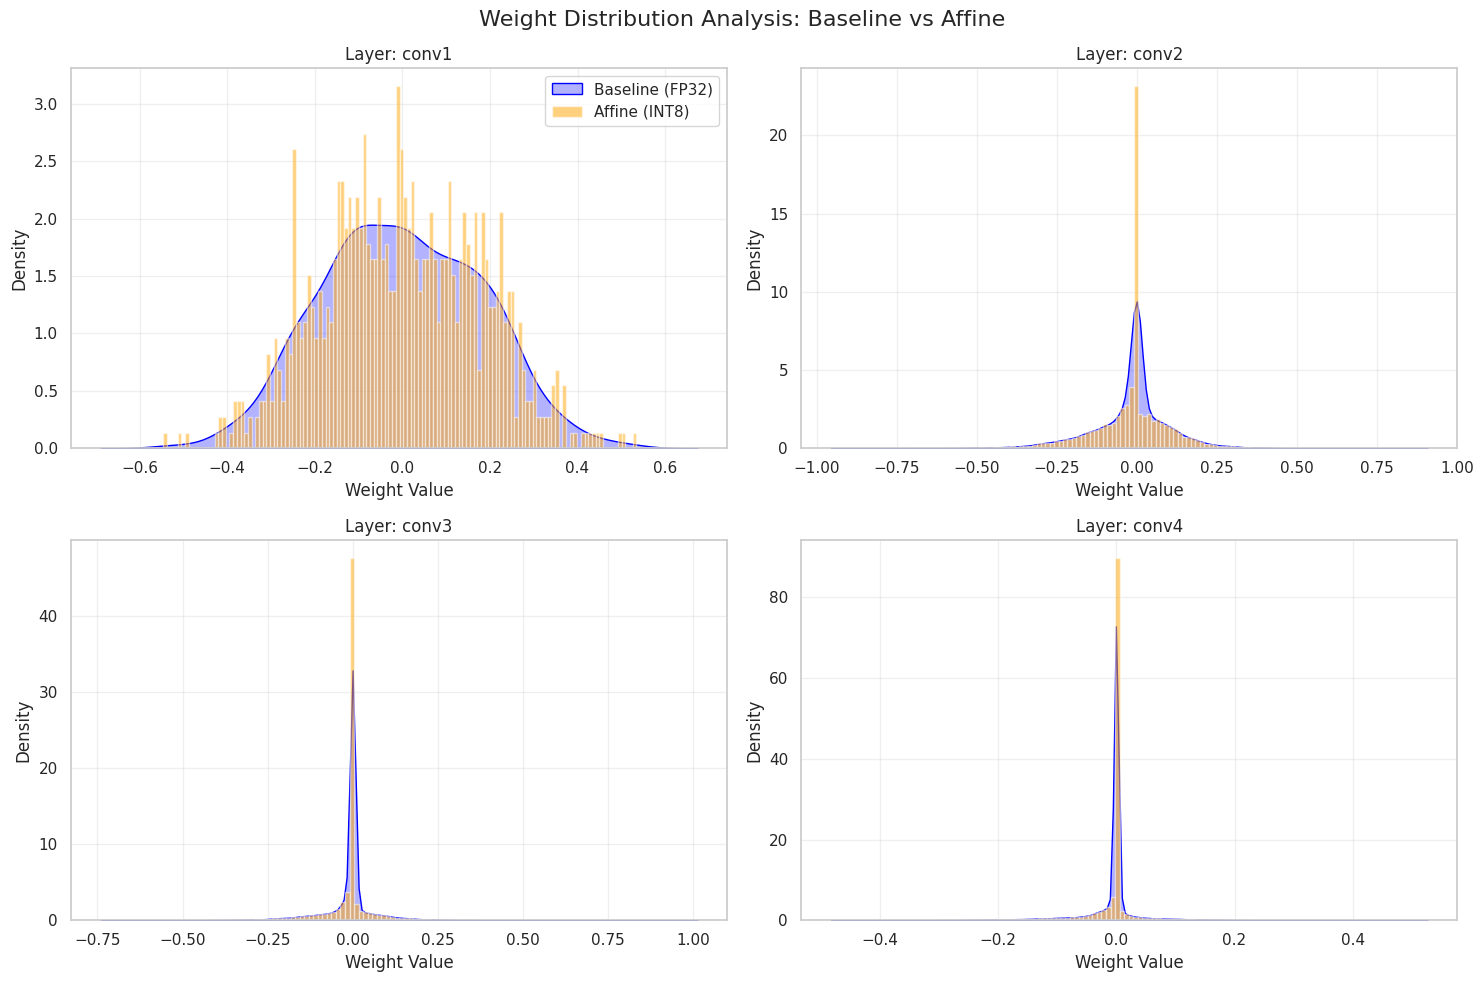

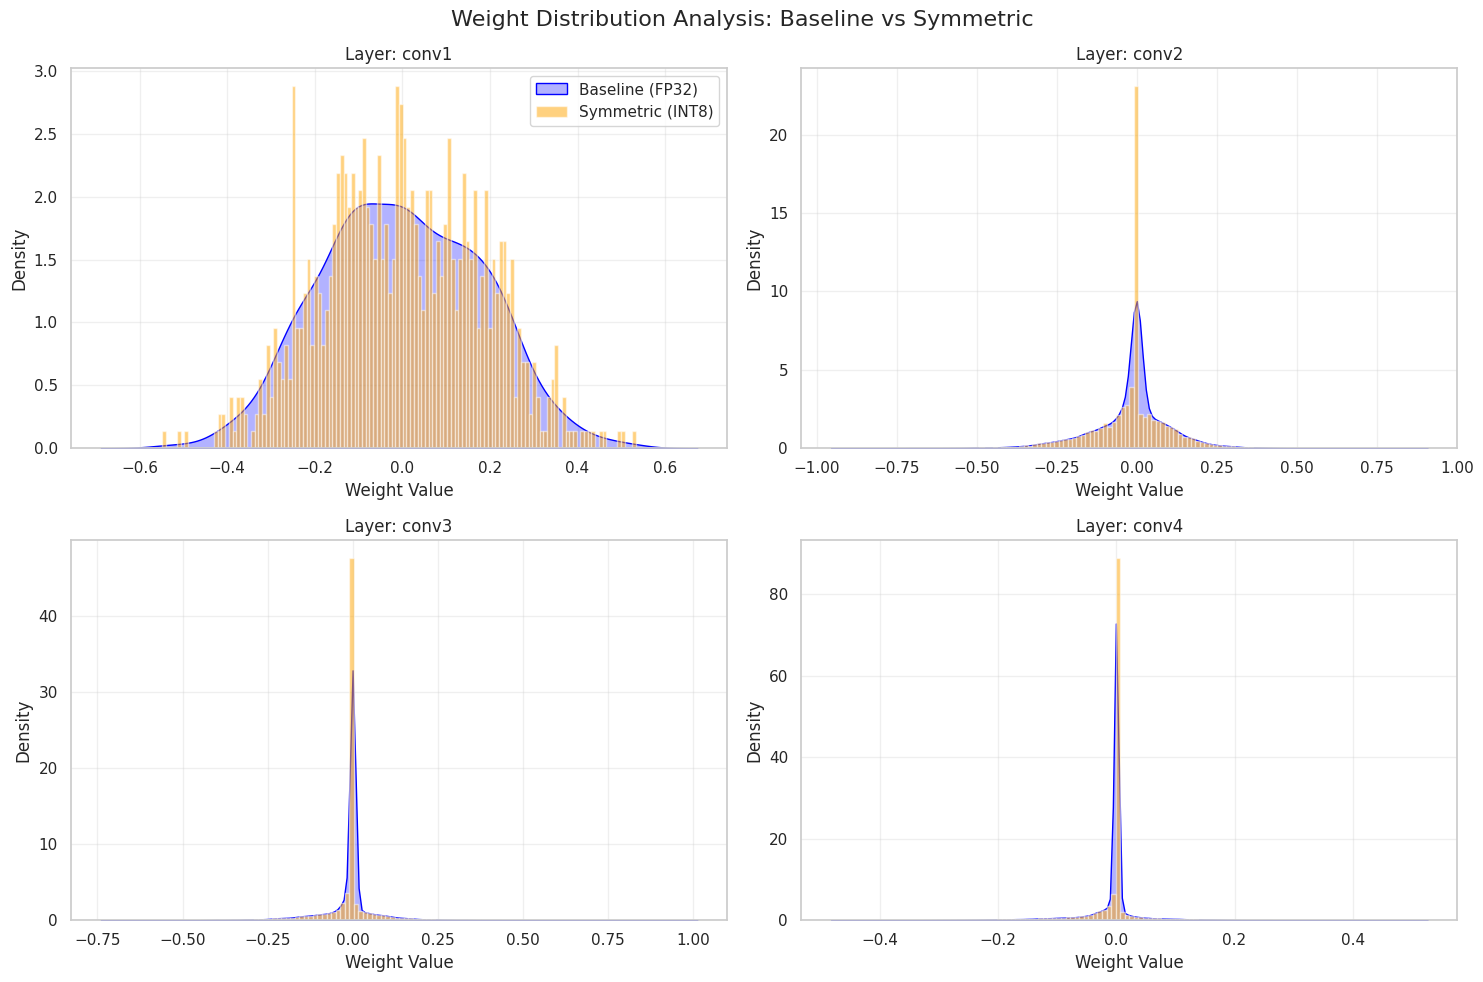

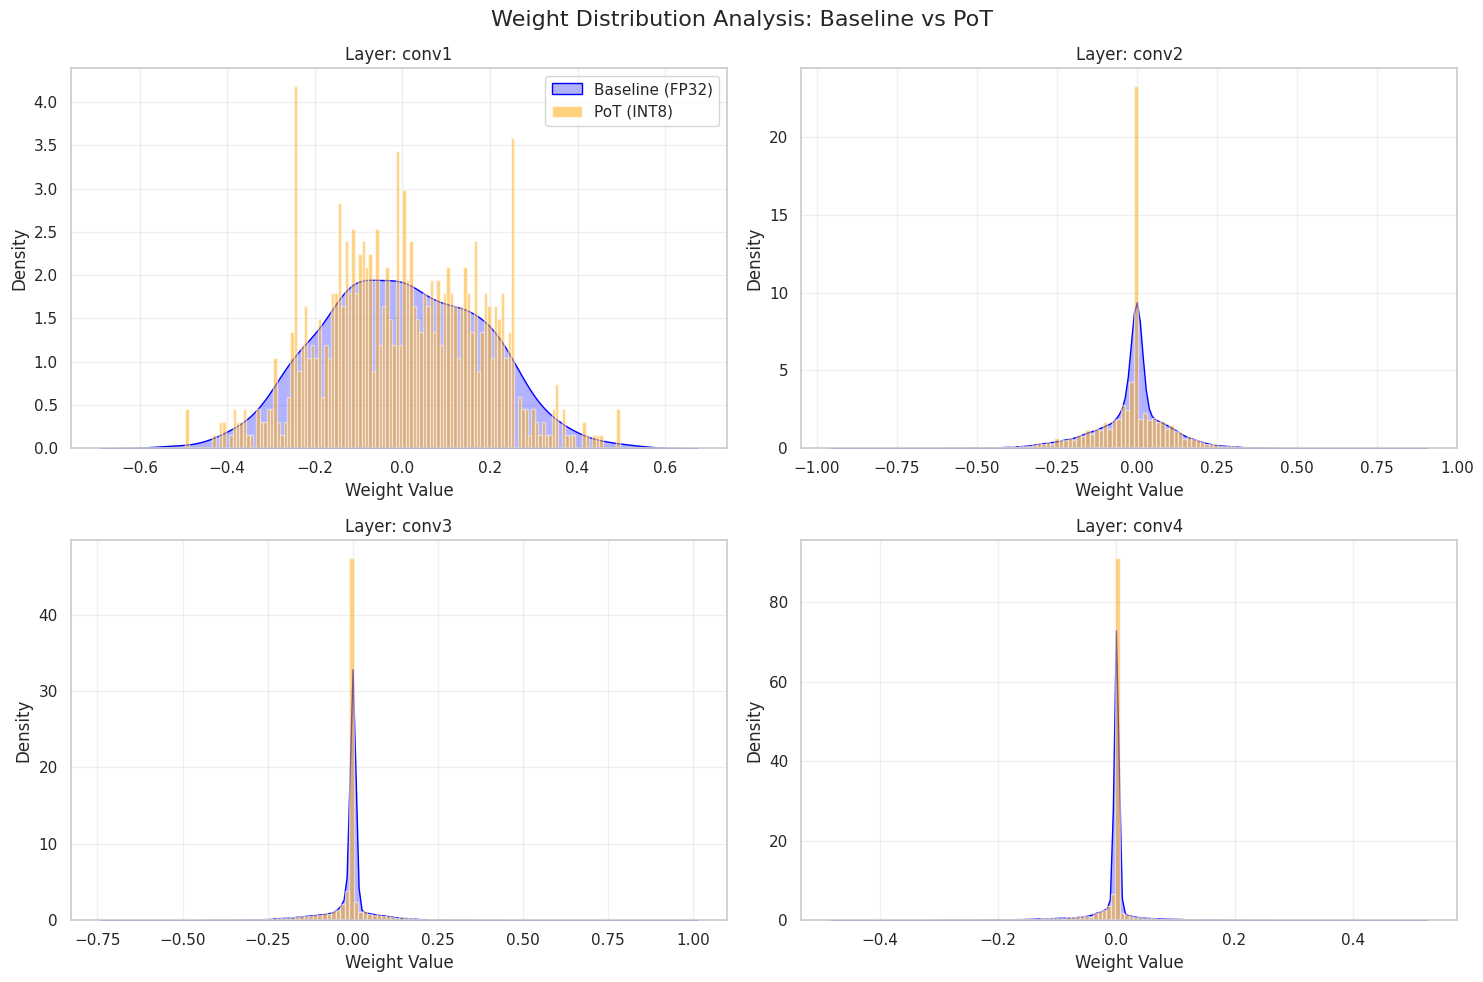

In [7]:
def plot_weight_histograms(baseline, quantized, quant_name):
    """
    Plots the continuous distribution of Baseline weights vs. 
    the discrete distribution of Quantized weights.
    """
    layers = ['conv1', 'conv2', 'conv3', 'conv4']

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f"Weight Distribution Analysis: Baseline vs {quant_name}", fontsize=16)
    axes = axes.flatten()
    
    for i, layer_name in enumerate(layers):
        ax = axes[i]
        if not hasattr(baseline, layer_name) or not hasattr(quantized, layer_name):
            ax.text(0.5, 0.5, f"{layer_name} not found", ha='center')
            continue
        base_layer = getattr(baseline, layer_name)
        w_base = base_layer.weight.detach().cpu().numpy().flatten()
        
        quant_layer = getattr(quantized, layer_name)
        if hasattr(quant_layer, '_packed_params'):
            w_quant_packed = quant_layer._packed_params.unpack()[0]
            w_quant = w_quant_packed.dequantize().detach().cpu().numpy().flatten()
        else:
            ax.text(0.5, 0.5, "Not quantized/packed", ha='center')
            continue
    
        # Baseline: Smooth curve (KDE)
        sns.kdeplot(w_base, color='blue', fill=True, label='Baseline (FP32)', alpha=0.3, ax=ax)
        
        # Quantized: Discrete bins (Histogram)
        # We increase bins to 128 to show the discrete steps clearly
        ax.hist(w_quant, bins=128, color='orange', alpha=0.5, label=f'{quant_name} (INT8)', density=True)
        
        ax.set_title(f"Layer: {layer_name}")
        ax.set_xlabel("Weight Value")
        ax.set_ylabel("Density")
        if i == 0:
            ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Run Visualization (Compare Baseline vs Affine)
print("\n--- Visualizing Quantization Effects ---")
    
model_base = load_model("Baseline", num_classes)
model_aff = load_model("Affine", num_classes)

if model_base and model_aff:
    plot_weight_histograms(model_base, model_aff, "Affine")

model_sym = load_model("Symmetric", num_classes)

if model_base and model_sym:
    plot_weight_histograms(model_base, model_sym, "Symmetric")

model_pot = load_model("PoT", num_classes)

if model_base and model_pot:
    plot_weight_histograms(model_base, model_pot, "PoT")